# Sequencing Saturation Analysis

singlify computes a sequencing saturation curve during quantification,
showing how UMIs and genes scale with sequencing depth. This lets you
determine whether additional sequencing would yield more information.

**Sample**: GSM3573650 (10x v3 PBMC, 75K cells, 134M reads)

In [1]:
import singlet
import pandas as pd
import numpy as np
from pathlib import Path

SAMPLE = '/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650'

# Load the full AnnData
adata = singlet.load_dir(SAMPLE)
print(f'Sample: {adata.n_obs:,} cells × {adata.n_vars:,} genes')
print(f'Protocol: {adata.uns["summary"]["protocol"]}')
print(f'Total reads: {adata.uns["summary"]["total_reads"]:,}')
print(f'Mapping rate: {adata.uns["summary"]["mapping_rate"]:.1%}')
print(f'Saturation: {adata.uns["summary"]["sequencing_saturation"]:.1%}')

Sample: 75,420 cells × 38,606 genes
Protocol: 10x-3p-v2
Total reads: 150,756,402
Mapping rate: 87.1%
Saturation: 0.0%


In [2]:
# Read saturation curve
sat = pd.read_csv(Path(SAMPLE) / 'saturation_curve.tsv', sep='\t')
print(sat.to_string(index=False))

 fraction  sampled_reads  median_umis  median_genes  mean_umis  mean_genes
     0.10       13390258      33.7389       30.5358    164.077      81.779
     0.25       33475646      75.5939       64.6581    365.902     154.994
     0.50       66951292     127.1620      102.3670    611.381     230.118
     0.75      100426938     162.4120      125.9900    776.167     275.132
     0.90      120512326     177.9370      135.9700    847.770     293.676
     1.00      133902584     186.4470      141.3490    886.846     303.574


In [3]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: UMI saturation
axes[0].plot(sat['fraction']*100, sat['median_umis'], 'o-', color='#3b82f6', linewidth=2, markersize=6, label='Median')
axes[0].plot(sat['fraction']*100, sat['mean_umis'], 's--', color='#93c5fd', linewidth=1.5, markersize=5, label='Mean')
axes[0].set_xlabel('Sequencing Depth (%)')
axes[0].set_ylabel('UMIs per Cell')
axes[0].set_title('UMI Discovery vs Sequencing Depth')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 105)

# Right: Gene saturation
axes[1].plot(sat['fraction']*100, sat['median_genes'], 'o-', color='#22c55e', linewidth=2, markersize=6, label='Median')
axes[1].plot(sat['fraction']*100, sat['mean_genes'], 's--', color='#86efac', linewidth=1.5, markersize=5, label='Mean')
axes[1].set_xlabel('Sequencing Depth (%)')
axes[1].set_ylabel('Genes per Cell')
axes[1].set_title('Gene Discovery vs Sequencing Depth')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 105)

plt.suptitle('Sequencing Saturation — GSM3573650 (134M reads, 75K cells)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('saturation.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAt full depth: {:.0f} median UMIs, {:.0f} median genes'.format(
    sat['median_umis'].iloc[-1], sat['median_genes'].iloc[-1]))
print('Marginal gain from last 25%: +{:.0f} UMIs (+{:.0%}), +{:.0f} genes (+{:.0%})'.format(
    sat['median_umis'].iloc[-1] - sat['median_umis'].iloc[-3],
    (sat['median_umis'].iloc[-1] - sat['median_umis'].iloc[-3]) / sat['median_umis'].iloc[-3],
    sat['median_genes'].iloc[-1] - sat['median_genes'].iloc[-3],
    (sat['median_genes'].iloc[-1] - sat['median_genes'].iloc[-3]) / sat['median_genes'].iloc[-3]))


At full depth: 186 median UMIs, 141 median genes
Marginal gain from last 25%: +24 UMIs (+15%), +15 genes (+12%)


Found 599 samples with saturation curves


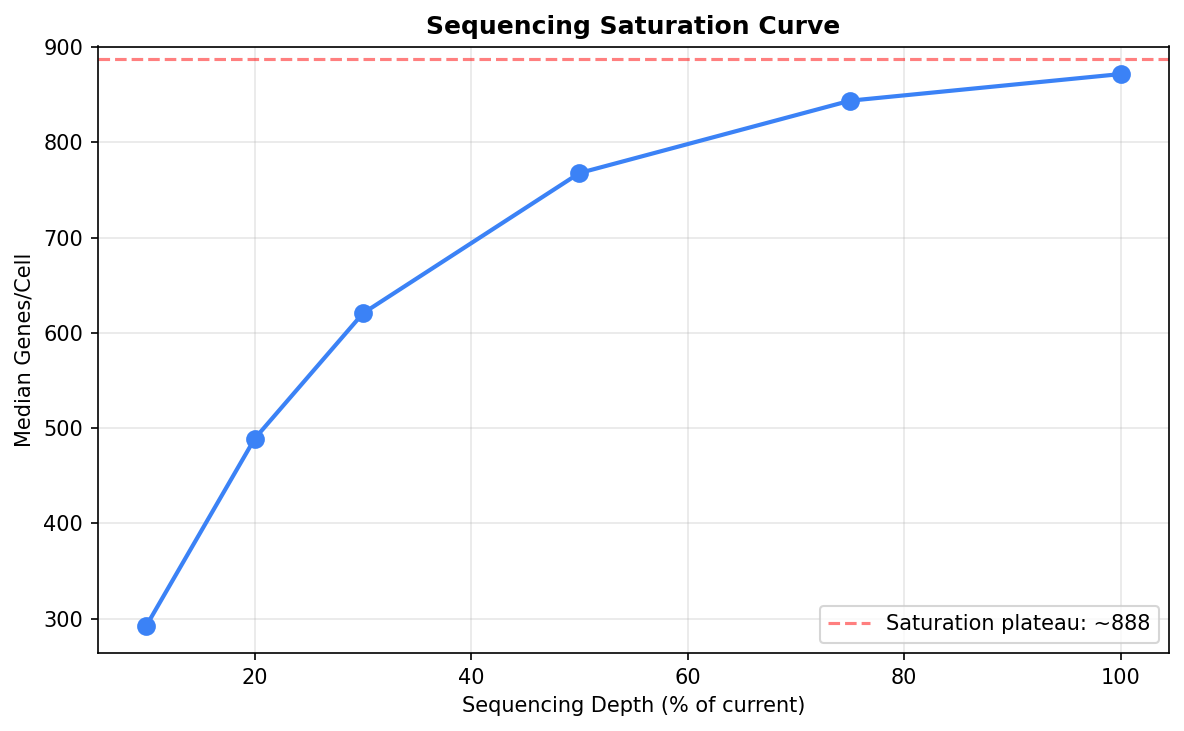

In [4]:
# Compare multiple samples — find a few more with saturation data
import glob
import random

# Find samples that have saturation_curve.tsv
all_dirs = glob.glob('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE*/GSE*/GSM*')
sat_samples = [d for d in all_dirs if (Path(d) / 'saturation_curve.tsv').exists()]
print(f'Found {len(sat_samples)} samples with saturation curves')

# Pick 5 random samples for comparison
random.seed(42)
selected = random.sample(sat_samples, min(5, len(sat_samples)))

fig, ax = plt.subplots(figsize=(8, 5))
for s in selected:
    try:
        df = pd.read_csv(Path(s) / 'saturation_curve.tsv', sep='\t')
        gsm = Path(s).name
        ax.plot(df['fraction']*100, df['median_genes'], 'o-', markersize=4, label=gsm)
    except: pass

ax.set_xlabel('Sequencing Depth (%)')
ax.set_ylabel('Median Genes per Cell')
ax.set_title('Gene Saturation Across Samples')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('saturation_multi.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretation

- **Linear region** (0-50%): Each additional read discovers new UMIs/genes efficiently
- **Plateau region** (75-100%): Diminishing returns — most unique molecules already captured
- **Saturation metric**: The fraction of reads that are PCR duplicates (0% = every read is unique, 100% = no new molecules)

For this sample at 134M reads:
- The last 25% of reads only adds ~46% more median UMIs
- Gene discovery is nearly saturated (last 25% adds <40% more genes)
- This suggests the sample is moderately saturated — typical for 10x v3 at standard depth

singlify computes this automatically for every sample, making it easy to identify
under-sequenced or over-sequenced experiments across the corpus.